# Functions

In [1]:
from segment_anything import SamPredictor, sam_model_registry
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import io

In [2]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

In [3]:
# pre-processes images to not exceed 100 KB of size

def preprocess_image(file_path, max_file_size_kb=100, step=10, quality=85):
    """
    Resize and compress the image to meet the file size requirement and return the image as a NumPy array for use with SamAutomaticMaskGenerator.

    Args:
    file_path (str): Path to the input image file.
    max_file_size_kb (int): Maximum file size in kilobytes.
    step (int): Decrease in size percentage with each iteration.
    quality (int): Compression quality.

    Returns:
    np.ndarray: Processed image as a NumPy array.
    """
    # Load the image
    img = Image.open(file_path)
    if img.mode == 'P':  # Check if the image is in 'P' mode
        img = img.convert('RGB')  # Convert to 'RGB'

    img_format = 'JPEG'  # Set format to JPEG for all images

    # Continuously adjust the image until it meets the size requirement
    while True:
        # Convert image to byte array to check size
        img_byte_arr = io.BytesIO()
        img.save(img_byte_arr, format=img_format, quality=quality)
        size_kb = len(img_byte_arr.getvalue()) / 1024

        # If size is acceptable, convert to NumPy array and return
        if size_kb <= max_file_size_kb:
            img_byte_arr.seek(0)  # Rewind the file pointer to the start
            img_final = Image.open(img_byte_arr)
            return np.array(img_final)

        # Reduce dimensions and quality for the next iteration
        new_width = int(img.width * ((100 - step) / 100))
        new_height = int(img.height * ((100 - step) / 100))
        img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
        quality = max(10, quality - 5)  # Avoid quality less than 10

# Implementation

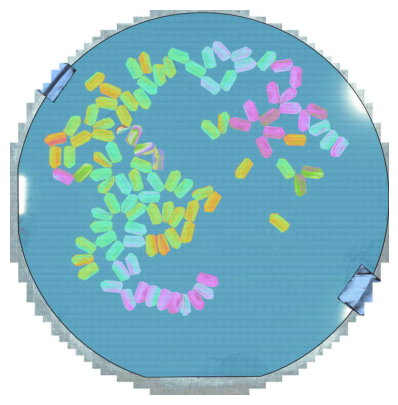

In [4]:
# upload, compress, and display image

filepath = "../images/wafer4_250nm_100sections_0.08mm-s_RGB.png"
filename = cv2.imread(filepath)
image = preprocess_image(filepath) # compressing the image
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plotting
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis('off')
plt.show()

In [29]:
# setting up model DESCRIBE LINE BY LINE WHAT EACH ONE DOES

model_type = "vit_h"
checkpoint = "../models/sam_vit_h_4b8939.pth"

sam = sam_model_registry[model_type](checkpoint)
sam.to(device="cpu")

predictor = SamPredictor(sam)
predictor.set_image(image)

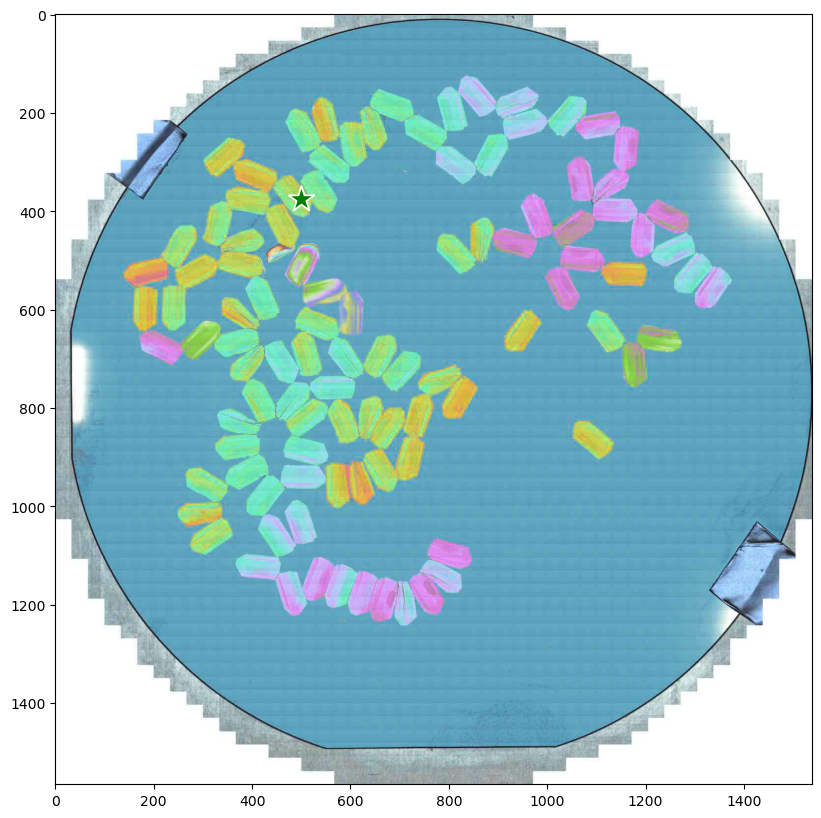

In [31]:
# example input CHANGE THIS

input_point = np.array([[500, 375]])
input_label = np.array([1])

# Plotting results

plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

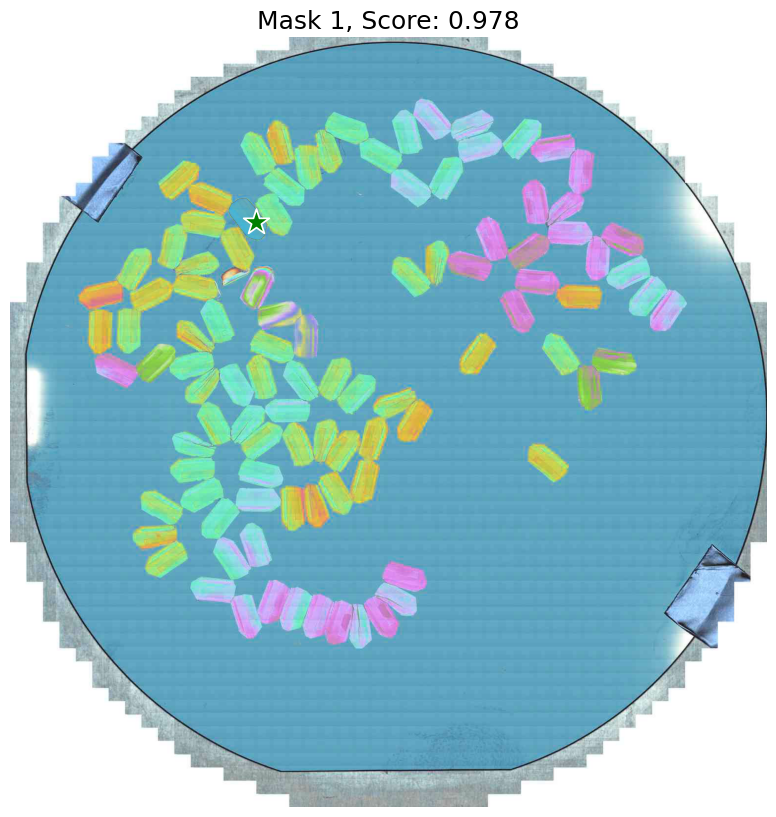

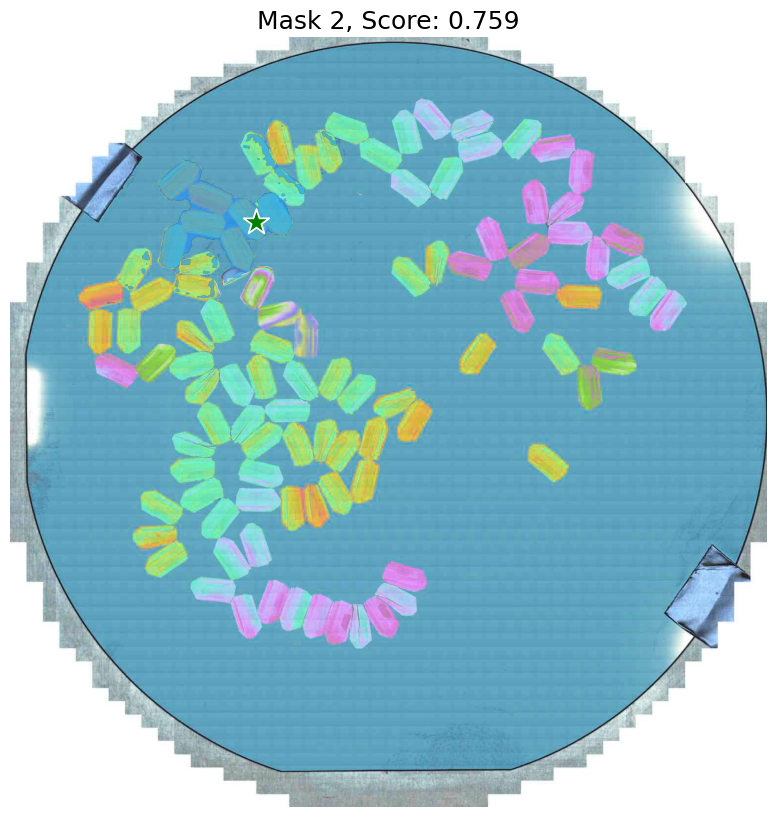

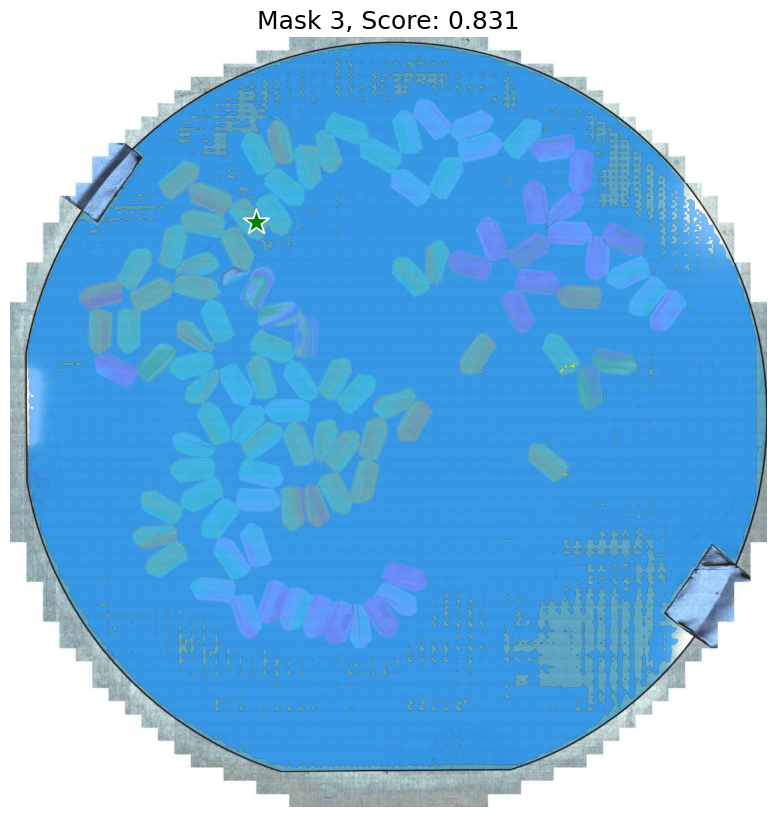

In [32]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()